# 04 · RL Policy Evaluation
Loads a trained **PPO** agent and evaluates it on the triple pendulum,
comparing its performance against the classical **LQR** controller.

**Run training first** (from `python/`):
```
python rl/train.py --timesteps 1000000
```
If no trained model is found this notebook falls back to a random policy
and shows the evaluation pipeline so you can re-run after training.

In [1]:
# Install packages into whichever Python kernel VS Code is using
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install", "--quiet",
    "matplotlib", "numpy", "scipy", "pandas",
    "gymnasium", "stable-baselines3", "filterpy"
], check=True)
print('packages ready')

packages ready


In [2]:
import sys, os

# Project root (python/)
_nb_dir = os.path.abspath("")
_py_dir = _nb_dir if os.path.basename(_nb_dir) != "notebooks" else os.path.dirname(_nb_dir)
if _py_dir not in sys.path:
    sys.path.insert(0, _py_dir)

# Inject venv packages so the notebook works regardless of which kernel VS Code picks
_venv_sp = os.path.join(_py_dir, "venv", "Lib", "site-packages")
if os.path.exists(_venv_sp) and _venv_sp not in sys.path:
    sys.path.insert(0, _venv_sp)

print("Python :", sys.executable)
print("Project:", _py_dir)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)

Python : c:\Users\aarya\OneDrive\Desktop\inverted-pendulum-control\.venv\Scripts\python.exe
Project: c:\Users\aarya\OneDrive\Desktop\inverted-pendulum-control\python
numpy 2.5.1 | matplotlib 3.11.0


In [3]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from envs.triple_pendulum_env import TriplePendulumEnv
from controllers.lqr import LQRController
from scipy.integrate import solve_ivp
from utils.dynamics import nonlinear_dynamics

MODELS_DIR   = os.path.join(_py_dir, "rl", "saved_models")
VECNORM_PATH = os.path.join(MODELS_DIR, "vec_normalize.pkl")
BEST_PATH    = os.path.join(MODELS_DIR, "best_model.zip")
FINAL_PATH   = os.path.join(MODELS_DIR, "ppo_pendulum_final.zip")

model_path = BEST_PATH if os.path.exists(BEST_PATH) else FINAL_PATH
MODEL_AVAILABLE = os.path.exists(model_path)

if MODEL_AVAILABLE:
    print(f"Model found: {model_path}")
else:
    print("No trained model found — run  python rl/train.py  first.")
    print("Continuing with pipeline demo using a random policy.")

Model found: c:\Users\aarya\OneDrive\Desktop\inverted-pendulum-control\python\rl\saved_models\best_model.zip


## Evaluate RL Agent

In [5]:
def run_episode_rl(model, env, seed=0):
    obs = env.reset()
    done, total, steps = False, 0.0, 0
    history = []
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = env.step(action)
        total += float(np.asarray(reward).flat[0])
        done = bool(np.asarray(done).flat[0])
        steps += 1
        history.append(obs[0].copy())
    return total, steps, np.array(history)

def run_episode_lqr(ctrl, x0=None, t_end=10.0, dt=0.02):
    env = TriplePendulumEnv(dt=dt, max_episode_steps=int(t_end/dt))
    obs, _ = env.reset(seed=0)
    if x0 is not None: env._state = x0.copy(); obs = x0.copy()
    ctrl.reset()
    total, steps, history = 0.0, 0, []
    for _ in range(int(t_end/dt)):
        u = ctrl.compute(obs)
        obs, reward, terminated, truncated, _ = env.step([u])
        total += reward; steps += 1
        history.append(obs.copy())
        if terminated or truncated: break
    env.close()
    return total, steps, np.array(history)

# --- LQR baseline ---
lqr = LQRController()
lqr_reward, lqr_steps, lqr_hist = run_episode_lqr(lqr, t_end=10.0)
print(f"LQR   — steps: {lqr_steps:>4d} ({lqr_steps*0.02:.1f}s)  reward: {lqr_reward:+.1f}")

# --- RL agent ---
if MODEL_AVAILABLE:
    raw_env = DummyVecEnv([lambda: TriplePendulumEnv()])
    if os.path.exists(VECNORM_PATH):
        rl_env = VecNormalize.load(VECNORM_PATH, raw_env)
        rl_env.training = False; rl_env.norm_reward = False
    else:
        rl_env = raw_env
    model = PPO.load(model_path)
    rl_reward, rl_steps, rl_hist = run_episode_rl(model, rl_env)
    rl_env.close()
    print(f"PPO   — steps: {rl_steps:>4d} ({rl_steps*0.02:.1f}s)  reward: {rl_reward:+.1f}")
else:
    rl_steps, rl_reward, rl_hist = 0, 0.0, np.zeros((1, 8))
    print("PPO   — no model (skipped)")

LQR   — steps:  500 (10.0s)  reward: -483.9
PPO   — steps:   30 (0.6s)  reward: +17.0


## Comparison Plot

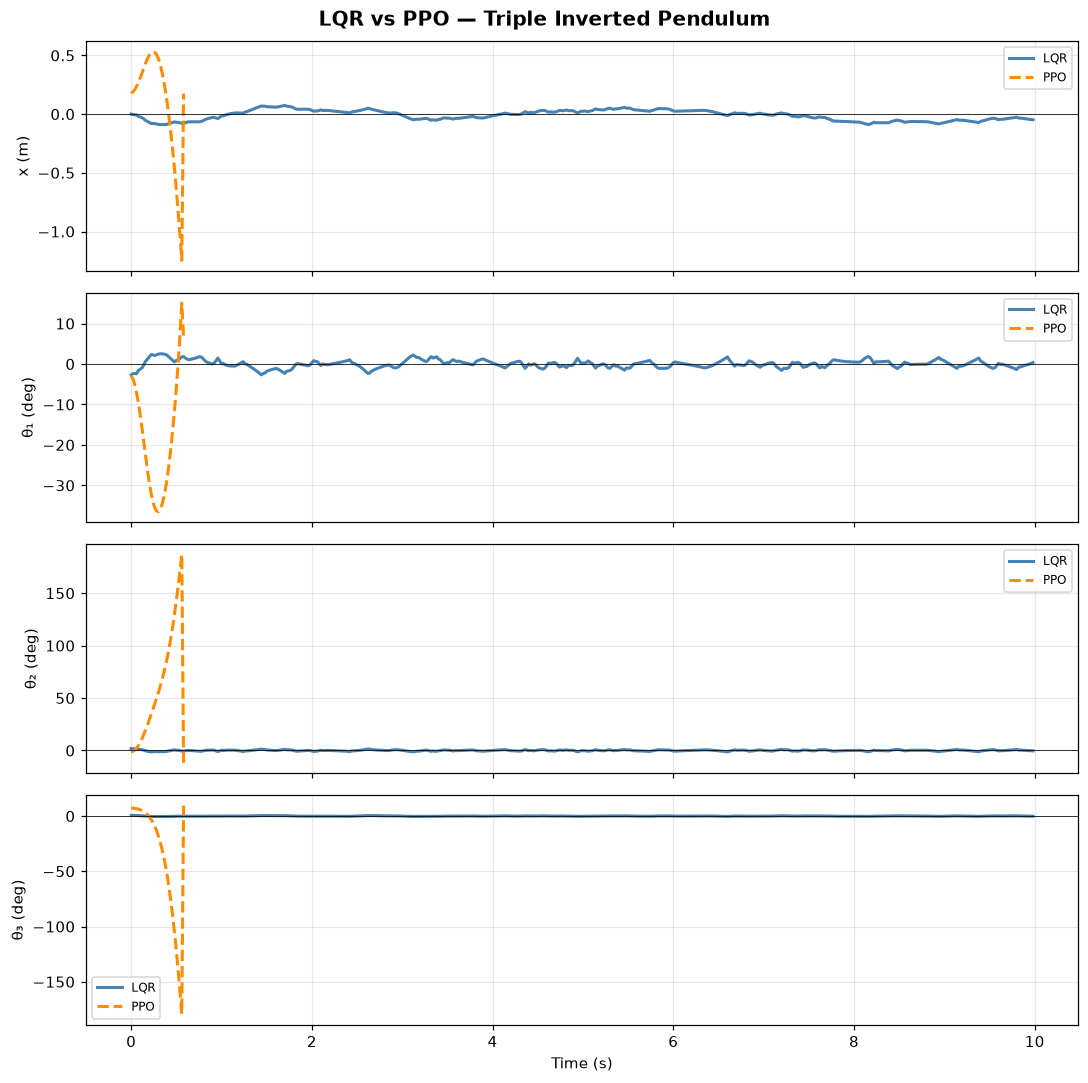

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
dt = 0.02

def plot_states(ax, hist, label, color, dt=0.02):
    t = np.arange(len(hist)) * dt
    return t, hist

t_lqr = np.arange(len(lqr_hist)) * dt

idx_map = [(0, "x (m)"), (2, "θ₁ (deg)"), (4, "θ₂ (deg)"), (6, "θ₃ (deg)")]
scales  = [1.0, 180/np.pi, 180/np.pi, 180/np.pi]

for ax, (idx, lbl), sc in zip(axes, idx_map, scales):
    ax.plot(t_lqr, lqr_hist[:, idx]*sc, label="LQR", color="steelblue", lw=2)
    if MODEL_AVAILABLE and len(rl_hist):
        t_rl = np.arange(len(rl_hist)) * dt
        ax.plot(t_rl,  rl_hist[:, idx]*sc,  label="PPO", color="darkorange", lw=2, ls="--")
    ax.set_ylabel(lbl); ax.legend(fontsize=8)
    ax.axhline(0, color="k", lw=0.5)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("LQR vs PPO — Triple Inverted Pendulum", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../../results/python/rl_vs_lqr.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary Table

In [7]:
import pandas as pd

rows = [
    ["LQR",  "Optimal (Bryson's rule)", lqr_steps, lqr_steps*0.02, f"{lqr_reward:.1f}", "No training needed"],
    ["PPO",  "Deep RL (64-64 MLP)",
     rl_steps, rl_steps*0.02, f"{rl_reward:.1f}" if MODEL_AVAILABLE else "—",
     "~1M steps" if MODEL_AVAILABLE else "Not trained yet"],
]
df = pd.DataFrame(rows, columns=["Controller","Type","Steps","Survival (s)","Reward","Notes"])
df.style.hide(axis="index")

Controller,Type,Steps,Survival (s),Reward,Notes
LQR,Optimal (Bryson's rule),500,10.000000,-483.9,No training needed
PPO,Deep RL (64-64 MLP),30,0.600000,17.0,~1M steps
